In [1]:
import seaborn as sns
import numpy as np

### problems in this test are completely the subset of scanpy_2. No value of this test.

# query

Provide the python code for plotting the ranking of genes with the API only from Scanpy. Apply it to the built-in pbmc3k processed dataset.

# old

In [2]:
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Normalization step (if necessary)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Identify highly variable genes (if not yet done)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Re-run the PCA and clustering after identifying highly variable genes
adata = adata[:, adata.var.highly_variable]
sc.tl.pca(adata, svd_solver='arpack')

# Clustering the data
sc.pp.neighbors(adata)
sc.tl.leiden(adata)

# Find marker genes
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')

# Plot ranking of marker genes for each cluster
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:383: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


TypeError: putmask: first argument must be an array

### sol 1: remove preprocessing normalize_total and log1p

### As per analysis of scanpy_2, norm and log1p should be removed

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:314: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_36162/2106638368.py:19: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


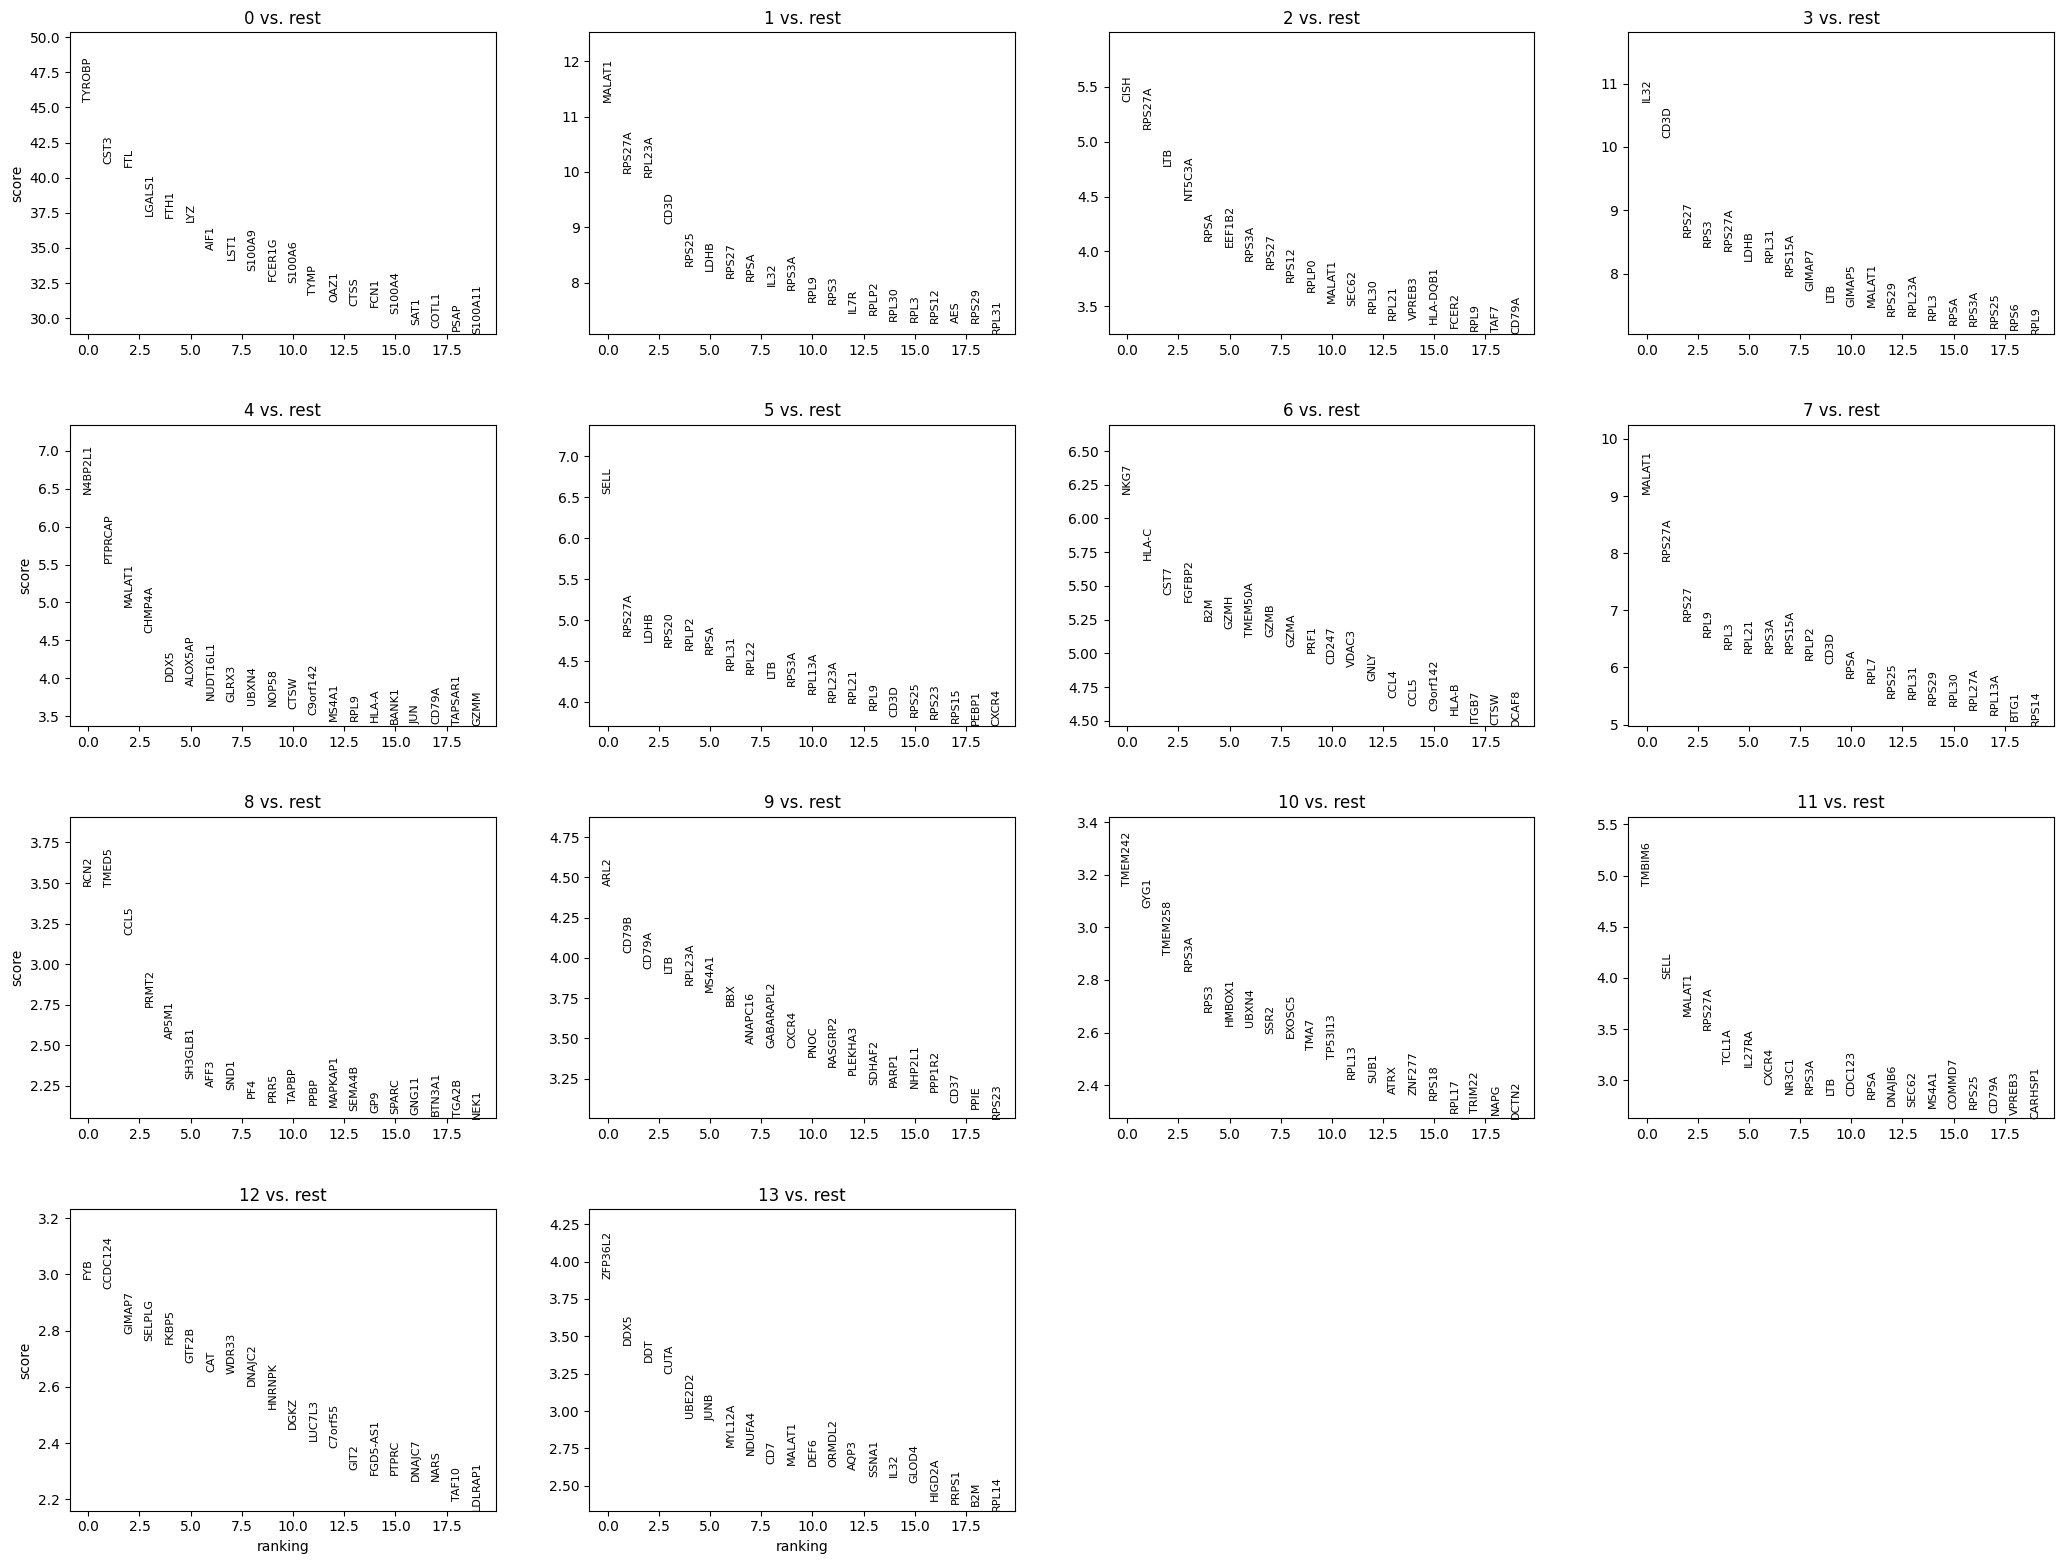

In [3]:
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k_processed()

# Normalization step (if necessary)
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

# Identify highly variable genes (if not yet done)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Re-run the PCA and clustering after identifying highly variable genes
adata = adata[:, adata.var.highly_variable]
sc.tl.pca(adata, svd_solver='arpack')

# Clustering the data
sc.pp.neighbors(adata)
sc.tl.leiden(adata)

# Find marker genes
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')

# Plot ranking of marker genes for each cluster
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

### great! problem solved

### sol 2: using original data

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:314: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


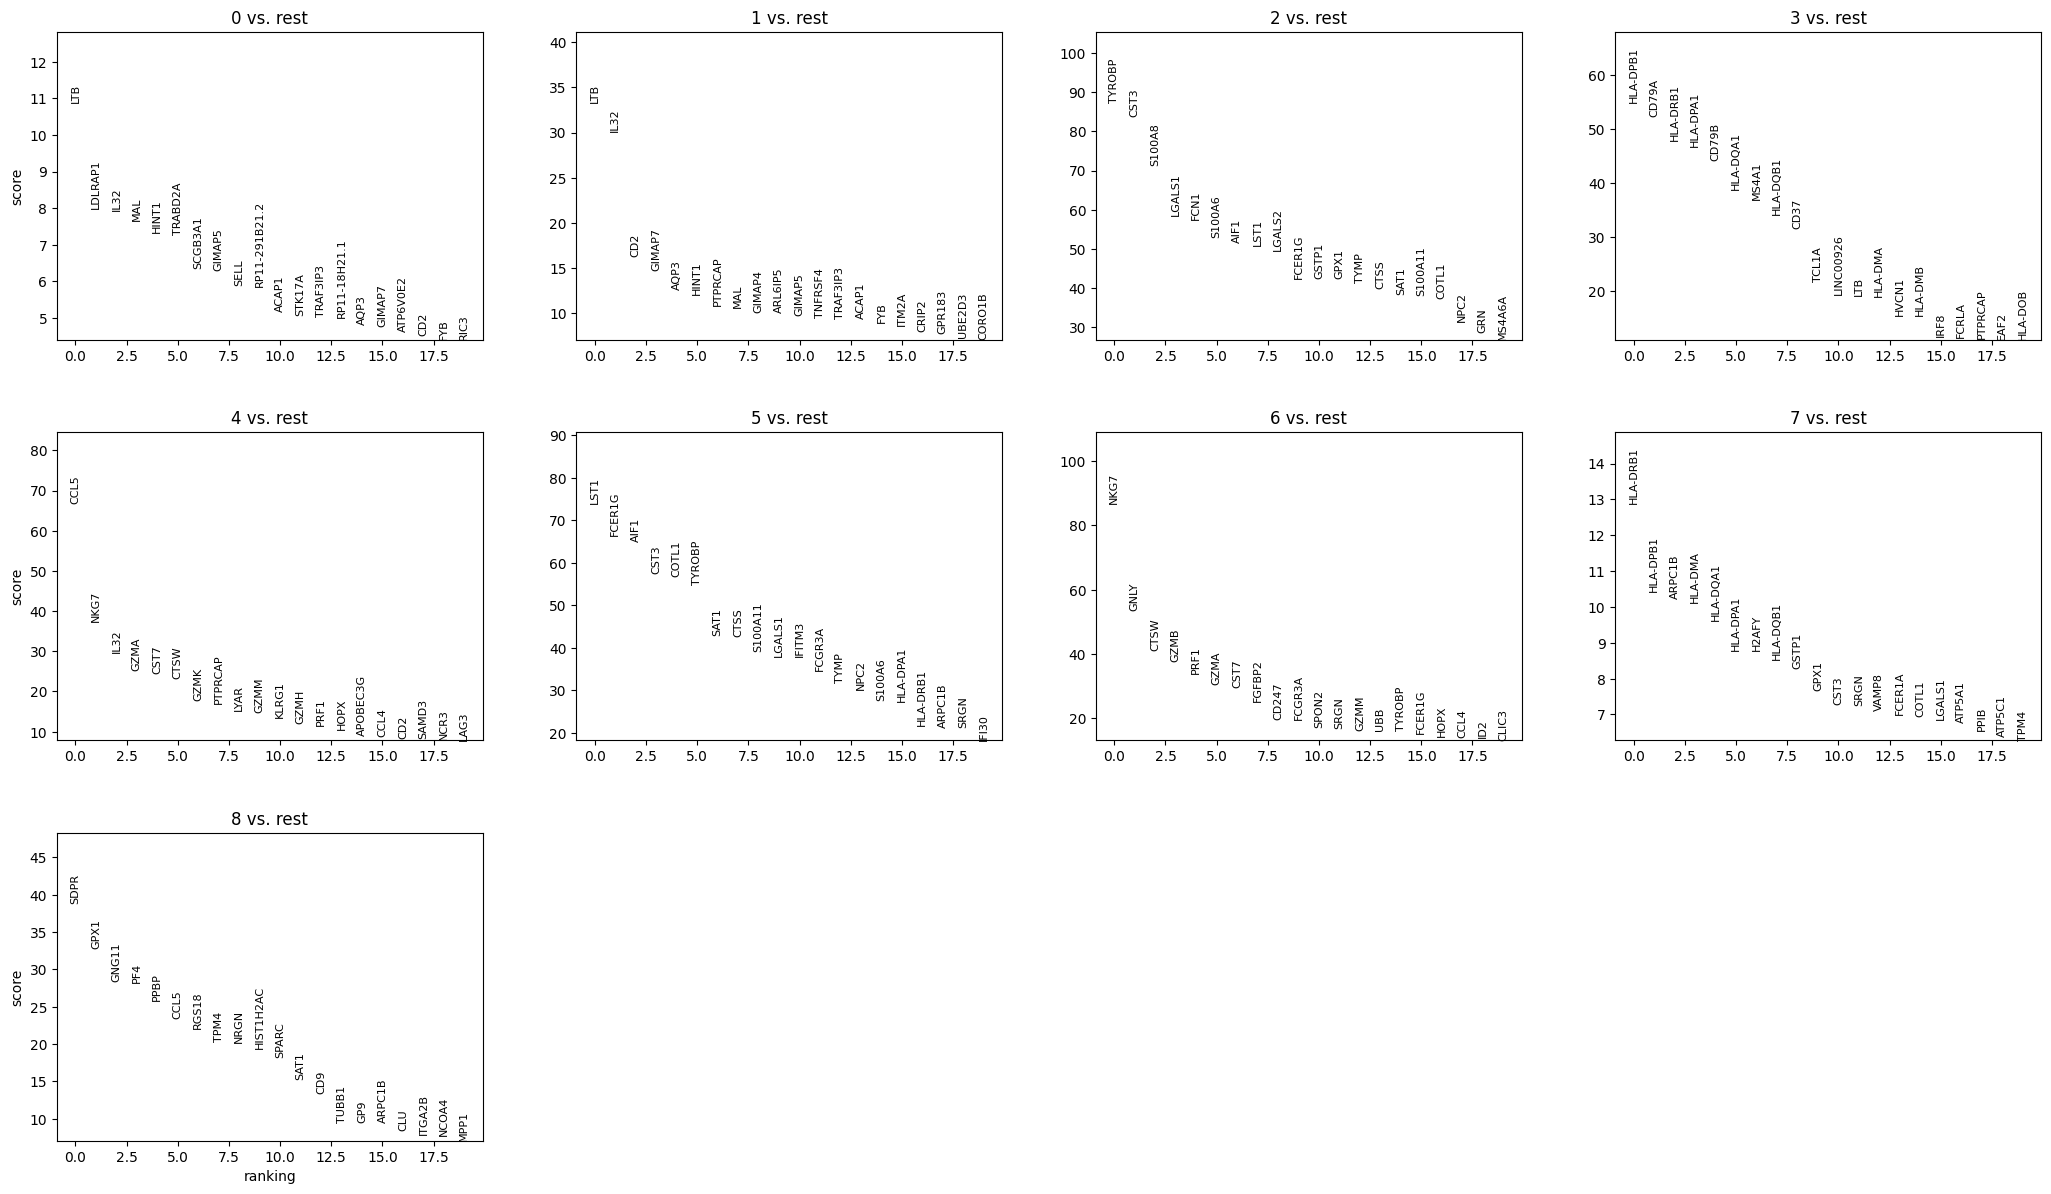

In [4]:
import scanpy as sc

# Load the example dataset
adata = sc.datasets.pbmc3k()

# Normalization step (if necessary)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Identify highly variable genes (if not yet done)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Re-run the PCA and clustering after identifying highly variable genes
adata = adata[:, adata.var.highly_variable]
sc.tl.pca(adata, svd_solver='arpack')

# Clustering the data
sc.pp.neighbors(adata)
sc.tl.leiden(adata)

# Find marker genes
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')

# Plot ranking of marker genes for each cluster
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

### great! it works, but results look slightly different.

# new

### no error, no need to test